# Titanic – Przewidywanie przeżycia pasażerów

**Baza Danych:** [Titanic – Machine Learning from Disaster (Kaggle)](https://www.kaggle.com/c/titanic)  
**Zadanie:** Klasyfikacja binarna – czy pasażer przeżył (`Survived`: 0/1)  


| Kolumna | Opis |
|---------|------|
| `Pclass` | Klasa biletu (1/2/3) |
| `Sex` | Płeć |
| `Age` | Wiek |
| `SibSp` | Liczba rodzeństwa/małżonków na pokładzie |
| `Parch` | Liczba rodziców/dzieci na pokładzie |
| `Fare` | Cena biletu |
| `Embarked` | Port zaokrętowania (C, Q, S) |
| `Survived` | **Zmienna docelowa: 1 = przeżył, 0 = nie przeżył** |


# Data loading and exploration

In [24]:
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O titanic.csv

--2026-06-10 23:01:14--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.01s   

2026-06-10 23:01:14 (4.31 MB/s) - ‘titanic.csv’ saved [60302/60302]



In [25]:
import pandas as pd
import numpy as np

def load_titanic_data(path="titanic.csv"):
    return pd.read_csv(path)

titanic = load_titanic_data()

In [26]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [27]:
print(titanic["Sex"].value_counts())
print()
print(titanic["Embarked"].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [28]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


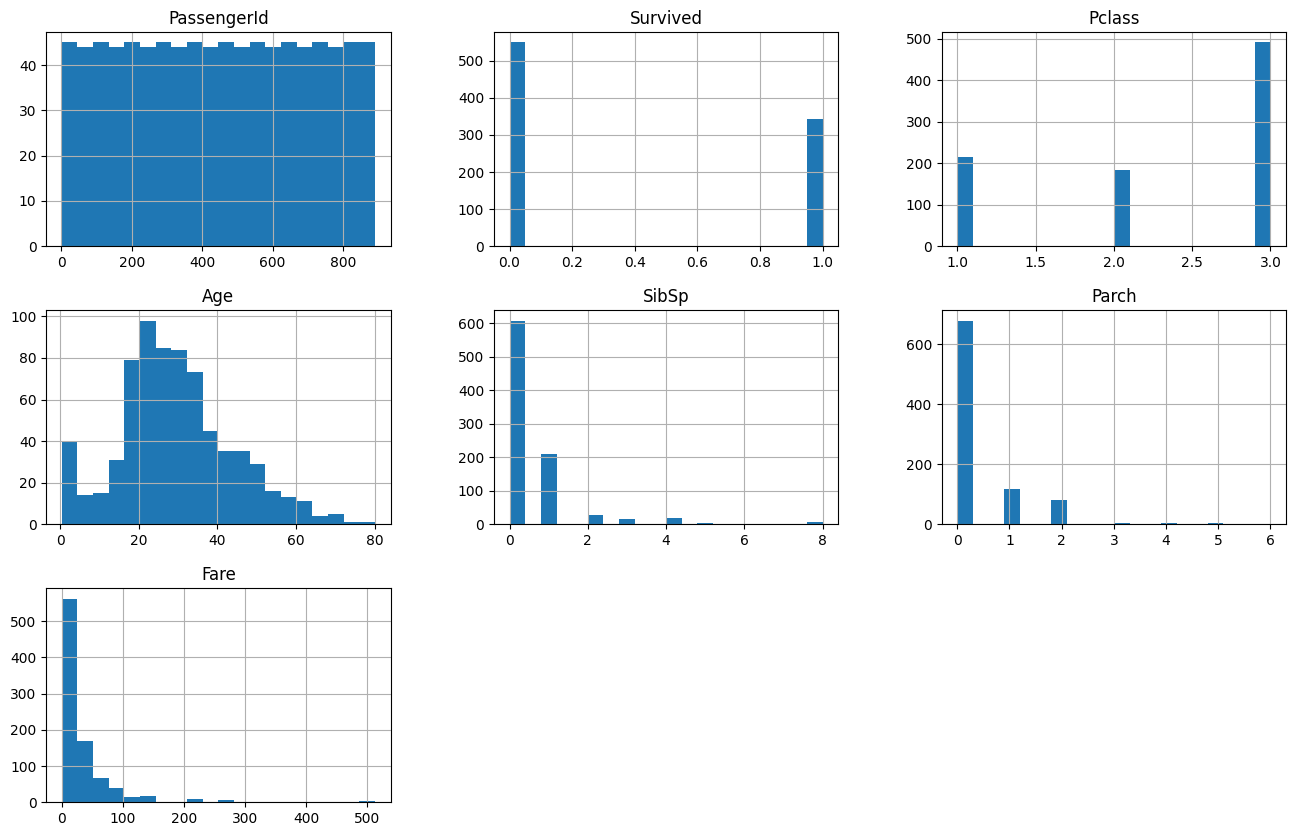

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
titanic.hist(bins=20, figsize=(16, 10))
plt.show()

## Train - test split

In [30]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(titanic, test_size=0.2, random_state=42)

- Data stratification
- Tworzymy kategorię `Pclass_cat` do stratyfikacji, żeby zachować proporcje klas biletów w zbiorach treningowym i testowym

In [31]:
titanic["Pclass_cat"] = titanic["Pclass"].clip(upper=3)

In [32]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(titanic, titanic["Pclass_cat"]):
    strat_train_set = titanic.loc[train_index]
    strat_test_set  = titanic.loc[test_index]

In [33]:
titanic["Pclass_cat"].value_counts() / len(titanic)

,count
Pclass_cat,
3,0.551066
1,0.242424
2,0.206510


In [34]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop(["Pclass_cat"], axis=1, inplace=True)

In [35]:
titanic = strat_train_set.copy()

## Visualisations and correlations

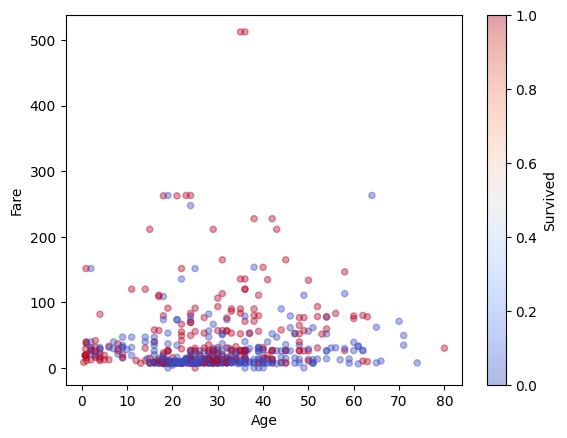

In [36]:
titanic.plot(kind="scatter", x="Age", y="Fare", alpha=0.4,
             c="Survived", cmap=plt.get_cmap("coolwarm"), colorbar=True)
plt.show()

In [37]:
attributes = ["Survived", "Fare", "Age", "SibSp", "Parch"]
titanic[attributes].corr()

,Survived,Fare,Age,SibSp,Parch
Survived,1.000000,0.251609,-0.070720,-0.060153,0.059978
Fare,0.251609,1.000000,0.097943,0.173691,0.240895
Age,-0.070720,0.097943,1.000000,-0.315303,-0.198696
SibSp,-0.060153,0.173691,-0.315303,1.000000,0.404848
Parch,0.059978,0.240895,-0.198696,0.404848,1.000000


array([[<Axes: xlabel='Survived', ylabel='Survived'>,
        <Axes: xlabel='Fare', ylabel='Survived'>,
        <Axes: xlabel='Age', ylabel='Survived'>,
        <Axes: xlabel='SibSp', ylabel='Survived'>,
        <Axes: xlabel='Parch', ylabel='Survived'>],
       [<Axes: xlabel='Survived', ylabel='Fare'>,
        <Axes: xlabel='Fare', ylabel='Fare'>,
        <Axes: xlabel='Age', ylabel='Fare'>,
        <Axes: xlabel='SibSp', ylabel='Fare'>,
        <Axes: xlabel='Parch', ylabel='Fare'>],
       [<Axes: xlabel='Survived', ylabel='Age'>,
        <Axes: xlabel='Fare', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='SibSp', ylabel='Age'>,
        <Axes: xlabel='Parch', ylabel='Age'>],
       [<Axes: xlabel='Survived', ylabel='SibSp'>,
        <Axes: xlabel='Fare', ylabel='SibSp'>,
        <Axes: xlabel='Age', ylabel='SibSp'>,
        <Axes: xlabel='SibSp', ylabel='SibSp'>,
        <Axes: xlabel='Parch', ylabel='SibSp'>],
       [<Axes: xlabel='Survived', yl

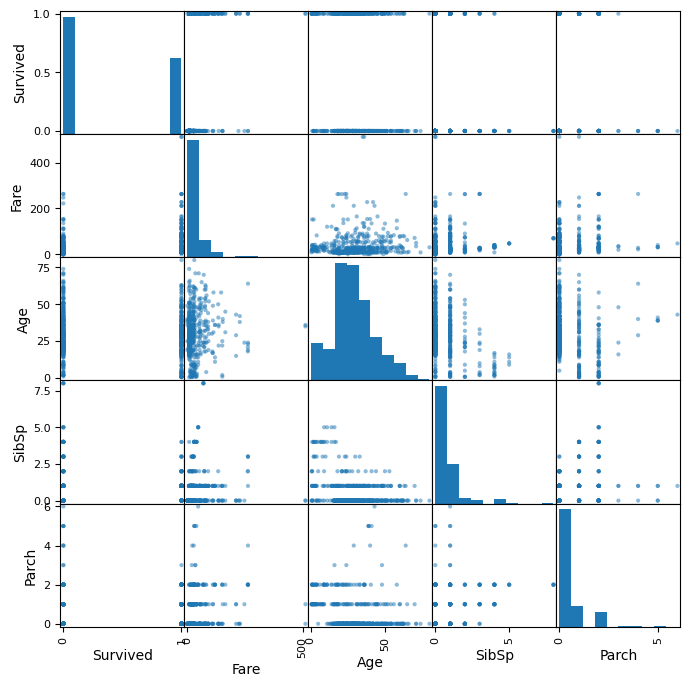

In [38]:
from pandas.plotting import scatter_matrix
attributes = ["Survived", "Fare", "Age", "SibSp", "Parch"]
scatter_matrix(titanic[attributes], figsize=(8, 8))

<Axes: xlabel='Fare', ylabel='Age'>

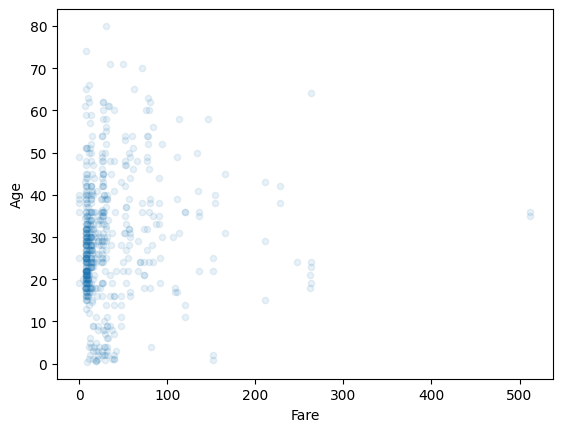

In [39]:
titanic.plot(kind="scatter", x="Fare", y="Age", alpha=0.1)

Additional columns

In [40]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [41]:
# nowa cecha: czy pasażer podróżował sam
titanic["is_alone"] = ((titanic["SibSp"] + titanic["Parch"]) == 0).astype(int)

In [42]:
# kodujemy Sex tymczasowo do korelacji
titanic_num = titanic.copy()
titanic_num["Sex"] = titanic_num["Sex"].map({"male": 0, "female": 1})
titanic_num = titanic_num.drop(["Name", "Ticket", "Cabin", "Embarked", "PassengerId"], axis=1)

In [43]:
# korelacja z dodatkowymi kolumnami
corr_mat = titanic_num.corr()
corr_mat["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Sex,0.558315
Fare,0.251609
Parch,0.059978
SibSp,-0.060153
Age,-0.070720
is_alone,-0.175592
Pclass,-0.334031


Label set separation!

In [44]:
titanic = strat_train_set.drop(["Survived", "Name", "Ticket", "Cabin", "PassengerId"], axis=1)
titanic_labels = strat_train_set["Survived"].copy()

In [45]:
titanic["is_alone"] = ((titanic["SibSp"] + titanic["Parch"]) == 0).astype(int)

# Data cleaning - pipeline

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_attribs = ["Pclass", "Age", "SibSp", "Parch", "Fare", "is_alone"]
cat_attribs = ["Sex", "Embarked"]

num_pipeline = Pipeline([
    ("imputer",    SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])
cat_pipeline = Pipeline([
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

In [47]:
full_pipeline = ColumnTransformer([
    ("num_pipeline", num_pipeline, num_attribs),
    ("cat_pipeline", cat_pipeline, cat_attribs),
])

titanic_prepared = full_pipeline.fit_transform(titanic)
titanic_prepared

array([[-1.56405658,  1.76806358,  0.44064412, ...,  0.        ,
         1.        ,  0.        ],
       [-0.36791449,  0.14731153, -0.49033099, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.8282276 , -0.16140314, -0.49033099, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.8282276 , -0.62447516, -0.49033099, ...,  0.        ,
         1.        ,  0.        ],
       [-1.56405658,  2.46267159, -0.49033099, ...,  0.        ,
         1.        ,  0.        ],
       [-0.36791449, -0.85601116, -0.49033099, ...,  0.        ,
         1.        ,  0.        ]])

In [48]:
titanic_prepared.shape

(712, 12)

In [49]:
pd.DataFrame(titanic_prepared)

,0,1,2,3,4,5,6,7,8,9,10,11
0,-1.564057,1.768064,0.440644,0.759653,1.259243,-1.224028,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.367914,0.147312,-0.490331,-0.478043,-0.447327,0.816974,0.0,1.0,0.0,0.0,1.0,0.0
2,0.828228,-0.161403,-0.490331,-0.478043,-0.485108,0.816974,0.0,1.0,0.0,0.0,1.0,0.0
3,0.828228,-0.084224,0.440644,-0.478043,-0.337326,-1.224028,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.367914,-0.315760,-0.490331,-0.478043,-0.395925,0.816974,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
707,0.828228,0.764741,0.440644,5.710436,-0.020171,-1.224028,0.0,1.0,0.0,0.0,1.0,0.0
708,-1.564057,1.304992,-0.490331,-0.478043,0.965219,0.816974,0.0,1.0,1.0,0.0,0.0,0.0
709,0.828228,-0.624475,-0.490331,-0.478043,-0.502842,0.816974,0.0,1.0,0.0,0.0,1.0,0.0
710,-1.564057,2.462672,-0.490331,-0.478043,0.001332,0.816974,0.0,1.0,0.0,0.0,1.0,0.0


# Logistic Regression Model

In [50]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(titanic_prepared, titanic_labels)

LogisticRegression(max_iter=1000, random_state=42)

In [51]:
from sklearn.metrics import classification_report
titanic_predictions = log_reg.predict(titanic_prepared)
print(classification_report(titanic_labels, titanic_predictions,
                             target_names=["Nie przeżył", "Przeżył"]))

              precision    recall  f1-score   support

 Nie przeżył       0.82      0.88      0.85       432
     Przeżył       0.79      0.71      0.75       280

    accuracy                           0.81       712
   macro avg       0.81      0.79      0.80       712
weighted avg       0.81      0.81      0.81       712



In [52]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [53]:
from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(log_reg, titanic_prepared, titanic_labels,
                            scoring="f1", cv=10)
lr_f1_scores = lr_scores
display_scores(lr_f1_scores)

Scores: [0.78571429 0.67857143 0.81481481 0.77777778 0.76363636 0.8
 0.76       0.625      0.73684211 0.65306122]
Mean: 0.7395418000267624
Standard deviation: 0.06183654543706574


# Decision Tree Classifier Model

In [54]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(titanic_prepared, titanic_labels)

DecisionTreeClassifier(random_state=42)

In [55]:
titanic_predictions = tree_clf.predict(titanic_prepared)
print(classification_report(titanic_labels, titanic_predictions,
                             target_names=["Nie przeżył", "Przeżył"]))

              precision    recall  f1-score   support

 Nie przeżył       0.97      1.00      0.99       432
     Przeżył       1.00      0.96      0.98       280

    accuracy                           0.98       712
   macro avg       0.99      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712



In [56]:
from sklearn.model_selection import cross_val_score

tree_scores = cross_val_score(tree_clf, titanic_prepared, titanic_labels,
                              scoring="f1", cv=10)
tree_f1_scores = tree_scores

In [57]:
display_scores(tree_f1_scores)

Scores: [0.79245283 0.6779661  0.70833333 0.86206897 0.79310345 0.78571429
 0.73684211 0.625      0.72727273 0.67924528]
Mean: 0.738799908027907
Standard deviation: 0.06669825739057639


# Random Forest Classifier Model

In [58]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(titanic_prepared, titanic_labels)

titanic_predictions = forest_clf.predict(titanic_prepared)
print(classification_report(titanic_labels, titanic_predictions,
                             target_names=["Nie przeżył", "Przeżył"]))

              precision    recall  f1-score   support

 Nie przeżył       0.98      0.99      0.99       432
     Przeżył       0.99      0.97      0.98       280

    accuracy                           0.98       712
   macro avg       0.98      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712



In [59]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(forest_clf, titanic_prepared, titanic_labels,
                         scoring="f1", cv=10)
forest_f1_scores = scores

In [60]:
display_scores(forest_f1_scores)

Scores: [0.75       0.73076923 0.76       0.82758621 0.81355932 0.87719298
 0.8        0.68       0.74576271 0.66666667]
Mean: 0.7651537120686895
Standard deviation: 0.062268236967076146


# Grid Search

In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_estimators": [3, 10, 30], "max_features": [2, 4, 6, 8]},
    {"bootstrap": [False], "n_estimators": [3, 10], "max_features": [2, 3, 4]},
]

forest_clf2 = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(forest_clf2, param_grid, cv=5,
                           scoring="f1",
                           return_train_score=True)
grid_search.fit(titanic_prepared, titanic_labels)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='f1')

In [62]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

In [63]:
grid_search.best_estimator_

RandomForestClassifier(max_features=4, n_estimators=30, random_state=42)

# Ocena na zbiorze testowym

In [64]:
best_model = grid_search.best_estimator_

In [65]:
X_test = strat_test_set.drop(["Survived", "Name", "Ticket", "Cabin", "PassengerId"], axis=1)
y_test = strat_test_set["Survived"].copy()

X_test["is_alone"] = ((X_test["SibSp"] + X_test["Parch"]) == 0).astype(int)

In [66]:
X_test_prepared = full_pipeline.transform(X_test)

In [67]:
test_pred = best_model.predict(X_test_prepared)

In [68]:
print(classification_report(y_test, test_pred,
                             target_names=["Nie przeżył", "Przeżył"]))

              precision    recall  f1-score   support

 Nie przeżył       0.85      0.89      0.87       117
     Przeżył       0.77      0.71      0.74        62

    accuracy                           0.83       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.83      0.82       179



# Randomized search

In [69]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

In [70]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

forest_clf3 = RandomForestClassifier(random_state=42)

final_pipeline = Pipeline([
    ("regressor", forest_clf3)
])

param_distribs = {
    "regressor__n_estimators": randint(low=3, high=200),
    "regressor__max_features": randint(low=2, high=8),
}

rnd_search = RandomizedSearchCV(
    final_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring="f1", random_state=42)

rnd_search.fit(titanic_prepared, titanic_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('regressor',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'regressor__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c523a065b80>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c5238db05f0>},
                   random_state=42, scoring='f1')

In [71]:
rnd_search.best_params_

{'regressor__max_features': 4, 'regressor__n_estimators': 90}

In [72]:
rnd_pred = rnd_search.best_estimator_.predict(X_test_prepared)
print(classification_report(y_test, rnd_pred,
                             target_names=["Nie przeżył", "Przeżył"]))

              precision    recall  f1-score   support

 Nie przeżył       0.85      0.88      0.87       117
     Przeżył       0.76      0.71      0.73        62

    accuracy                           0.82       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



# Porównanie modeli

In [73]:
from sklearn.metrics import f1_score

modele = {
    "Logistic Regression":          log_reg.predict(X_test_prepared),
    "Decision Tree":                tree_clf.predict(X_test_prepared),
    "Random Forest":                forest_clf.predict(X_test_prepared),
    "Random Forest (Grid Search)":  best_model.predict(X_test_prepared),
    "Random Forest (Rnd Search)":   rnd_search.best_estimator_.predict(X_test_prepared),
}

for nazwa, pred in modele.items():
    print(f"{nazwa}: F1 = {f1_score(y_test, pred):.4f}")

Logistic Regression: F1 = 0.6825
Decision Tree: F1 = 0.7302
Random Forest: F1 = 0.7273
Random Forest (Grid Search): F1 = 0.7395
Random Forest (Rnd Search): F1 = 0.7333


## Wnioski

1.  **Najlepszy model: Random Forest z Grid Search** – najwyższy F1-score na zbiorze testowym.
2.  **Decision Tree** przeuczony – perfect score na treningu, niższy na teście.
3.  **Logistic Regression** – dobry baseline, prosty i interpretowalny.
4.  **Najważniejsze cechy:** `Sex`, `Pclass`, `Fare`, `Age`, `is_alone`.